# Spotify

***Импорты***

In [1]:
import numpy as np # Основная библиотека для работы с табличными данными (DataFrames)
import pandas as pd # Библиотека для численных вычислений, работы с массивами и матрицами
import matplotlib.pyplot as plt # Основная библиотека для построения графиков
import seaborn as sns # Библиотека для статистической визуализации (построена на matplotlib)

***Данные***

In [2]:
df = pd.read_csv('dataset.csv')
df.head() # смотрим первые 5 строк

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

***Колонки в датасете***

- Track_id - идентификатор песни. Cлучайный набор цифр и латинских букв.
- Artists - имена артистов, работавших над песней. Если их несколько, то они указываются через ;. Является текстом.
- Album_name - название альбома. Является текстом.
- Track_name - название трека. Является текстом.
- Popularity - индекс популярности трека,принимает значения от 0 до 100 включительно. ТАРГЕТНАЯ ПЕРЕМЕННАЯ
- Duration_ms - длина песни в миллисекундах. Целое число.
- Explicit - наличие нецензурной лексики в треке. Булево значение -True\False.
- Danceability - показатель того, насколько песня подходит для танцев. Десятичная дробь от 0 до 1.
- Energy - показатель энергичности песни. Десятичная дробь от 0 до 1
- Key - тональность песни. Целое число от 0 до 11 включительно.
- Loudness - громкости песни. Десятичная дробь.
- Mode - режим аудиозаписи. Либо 0, либо 1.
- Speechiness - показатель словесности трека. Десятичная дробь от 0 до 1.
- Acousticness - показатель звучания песни, оценивает качество звука. Десятичная дробь от 0 до 1.
- Instrumentalness - показатель звучания инструментов в песне. Десятичная дробь от 0 до 1.
- Liveness - показатель живости(исполнение вживую, на концерте) песни. Десятичная дробь от 0 до 1.
- Valence - валентность песни, означает привлекательность звуков для человеческого слуха. Принимает значение в виде десятичной дроби от 0 до 1.
- Tempo - темп песни, указыватся в BPM (удары в минуту). Десятичная дробь.
- Time_signature - размер такта. Указывает, сколько ударов приходится на каждый такт песни. Целое число от 0 до 4.
- Track-genre - жанр песни. Является текстом.

***Распределение аудио-характеристик***

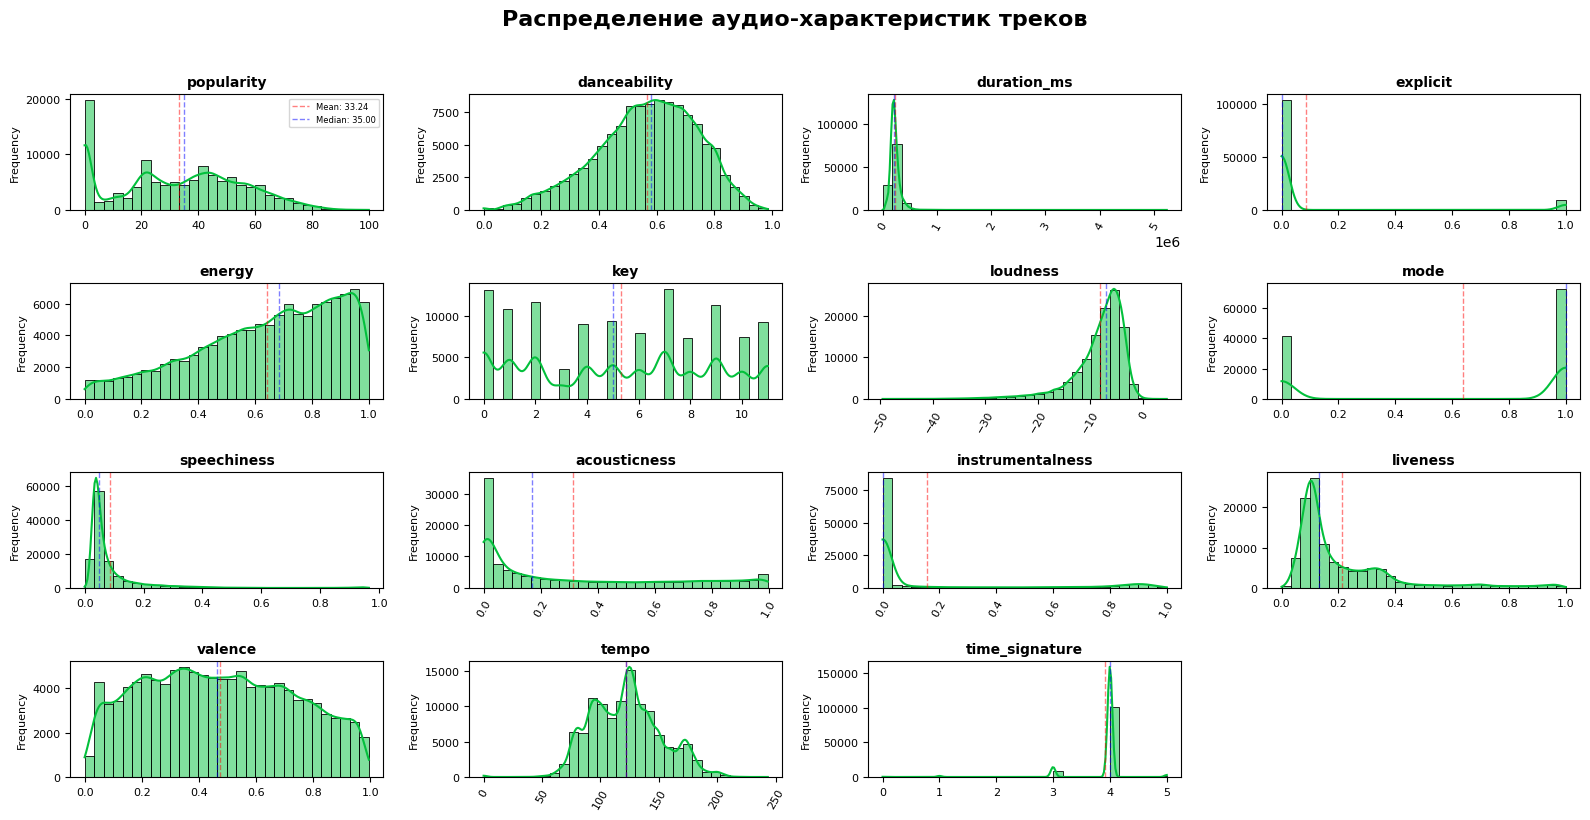

In [4]:
plt.figure(figsize=(16, 8))
features = ['popularity', 'danceability', 'duration_ms', 'explicit', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[feature], bins=30, kde=True, color='#03c03c', alpha=0.5)     # Гистограмма

    # Статистики на графике
    mean_val = df[feature].mean()
    median_val = df[feature].median()

    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'Median: {median_val:.2f}')
    plt.title(f'{feature}', fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Frequency', fontsize=8)

    # Поворот меток оси X при необходимости
    if len(str(df[feature].iloc[0])) > 5:  # Если значения длинные
        plt.xticks(rotation=60, fontsize=8)
    else:
        plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    # Легенда только для первого графика
    if i < 1:
        plt.legend(fontsize=6, loc='upper right')
plt.suptitle('Распределение аудио-характеристик треков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

1. **popularity**

Большинство треков имеют очень низкую популярность (0–20), а высоко-популярные треки (60+) - редкость. Ситуация для несбалансированных датасетов Spotify без фильтрации по чартам / топам.

2. **danceability**

Форма близка к нормальной, слегка левосторонняя асимметрия. Большинство треков находятся в диапазоне 0.4–0.8 (средняя и высокая танцевальность).

3. **duration_ms**

Форма сильно правосторонняя, острый пик около 2–3 минут, длинный хвост до примерно 10+ минут. Преобладают короткие треки (2–4 минуты), что соответствует современным трендам стриминга (TikTok, короткие плейлисты). Длинные треки (>6 мин) - редкость.

4. **explicit**

Форма бимодальная (0 и 1), примерно 80–85% треков без explicit (0).Большинство композиций чистые.

5. **energy**

Плотность растёт к 1.0. Среднее и медиана находятся в районе 0.6–0.7. Преобладают энергичные треки. Это характерно для современной поп-, танцевальной и электронной музыки.

6. **key**

Форма мультимодальная, почти равномерное распределение по 0–11 (12 тональностей). Тональность практически не смещена.

7. **loudness**

Форма левосторонняя, основной пик около –6…–4 dB. Современный мастеринг «громкой войны. Большинство треков нормализованы к высоким значениям громкости (–14…–3 dB).

8. **mode**

Форма бимодальная (0 = минор, 1 = мажор). Мажорных треков заметно больше. Типичная пропорция для поп-музыки (мажор чаще воспринимается как позитивный).

9. **speechiness**

Форма сильно правосторонняя, резкий пик у 0–0.1, длинный тонкий хвост. Подавляющее большинство это вокальные треки с низкой речевой составляющей.

10. **acoustiness**

Форма сильно правосторонняя, основной пик около 0.0–0.1. Преобладают неакустические (электронные, обработанные) треки. Акустические композиции явное меньшинство.

11. **instrumentalness**

Форма крайне правосторонняя, почти весь объём сосредоточен около 0.0. Инструментальные треки большая редкость. Выборка почти полностью вокальная.

12. **liveness**

Форма правосторонняя, основной пик 0.0–0.2, небольшой подъём около 0.3–0.4. Большинство треков студийные. Значения >0.8 (концертные записи) практически отсутствуют.

13. **valence**

Форма примерно симметричная, центр около 0.4–0.5.

14. **tempo**

Форма мультимодальная, основной пик около 120–130 BPM. Диапазон популярной музыки (dance-pop, hip-hop, EDM).

15. **time_signature**

Форма почти полностью сосредоточена на 4/4.

#### Вывод

- Выборка сильно смещена в сторону современной популярной / танцевальной музыки: высокие energy, danceability, loudness; низкие acoustiness, instrumentalness, speechiness, liveness.
- **popularity** имеет тяжёлое правое распределение  сильный дисбаланс классов (если, допустим,  решать задачу классификации высокая\низкая популярность).
- Длительность треков, speechiness и instrumentalness подтверждают преобладание коротких вокальных поп-/хип-хоп-/электронных композиций.

## Анализ и построение гипотез

***1. Популярность трека зависит от его длительности***

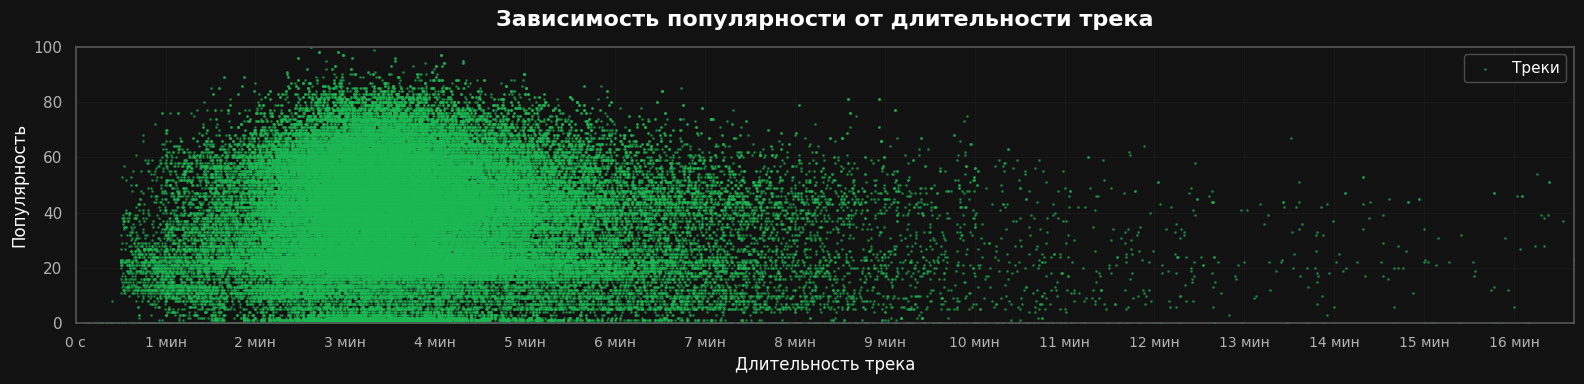

In [5]:
plt.style.use('dark_background')
sns.set_theme(style="dark", # установка темы
              rc={'figure.facecolor': '#121212',
                  'axes.facecolor':   '#121212',
                  'axes.edgecolor':   '#535353',
                  'axes.labelcolor':  '#FFFFFF',
                  'axes.titlecolor':  '#FFFFFF',
                  'xtick.color':      '#B3B3B3',
                  'ytick.color':      '#B3B3B3',
                  'grid.color':       '#282828',
                  'text.color':       '#FFFFFF',
                  'legend.facecolor': '#121212',
                  'legend.edgecolor': '#535353',
                  'legend.labelcolor': '#FFFFFF',
              })

valid_mask = (df['duration_ms'] >= 1) & (df['duration_ms'] <= 6000000)  # до 10 минут
df_valid = df[valid_mask].copy()

fig, ax = plt.subplots(figsize=(16, 4))
spotify_green = '#1DB954'

ax.scatter(df_valid['duration_ms'] / 1000,          # перевод в секунды
           df_valid['popularity'],
           marker='o',
           s=1,                                        # размер точек
           color=spotify_green,
           alpha=0.5,
           label='Треки')

# Оформление
ax.set_xlabel('Длительность трека', fontsize=12, color='#FFFFFF')
ax.set_ylabel('Популярность', fontsize=12, color='#FFFFFF')
ax.set_title('Зависимость популярности от длительности трека', fontsize=16, fontweight='bold', color='#FFFFFF', pad=15)
ax.legend(fontsize=11, loc='upper right', frameon=True, framealpha=0.9)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.5, color='#282828')
xticks_sec = np.arange(0, df_valid['duration_ms'].max()/1000 + 30, 60)  # каждые 60 сек
xticks_min = xticks_sec / 60
ax.set_xticks(xticks_sec)
ax.set_xticklabels([f'{int(m)} мин' if m >= 1 else f'{int(s)} с' for s, m in zip(xticks_sec, xticks_min)], fontsize=10, color='#B3B3B3')
# Лимиты осей чтобы не растягивать на выбросы
ax.set_xlim(0, 1000)                     # до 17 минут
ax.set_ylim(0, 100)
plt.tight_layout()

- Основная масса треков сосредоточена в диапазоне длительности от 1 до 5-6 минут (90–300 секунд).  
- Наблюдается очень резкое падение плотности точек после 5-6 минут.  
- Треки длиннее примерно 10 минут встречаются крайне редко и, как правило, имеют низкую популярность.  

#### Вывод

Длительность трека демонстрирует нелинейную зависимость с популярностью в датасете. Треки короче 5 минут имеют более высокий потенциал достижения высокой популярности, тогда как длительность свыше 6-7 минут становится серьёзным ограничивающим фактором в условиях современной модели потребления музыки на стриминговых платформах.

***2. Популярность трека зависит от его громкости***

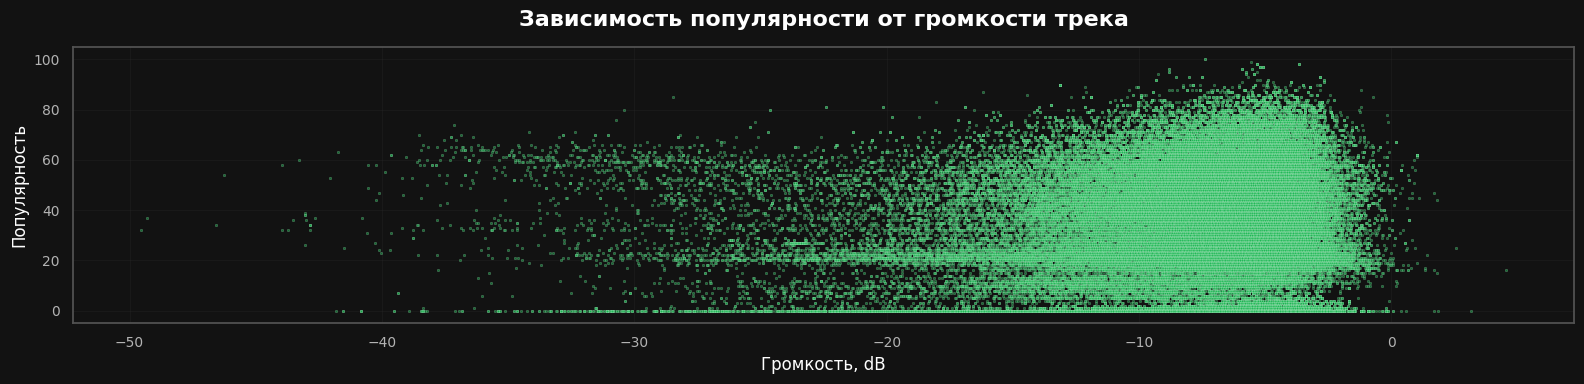

In [6]:
plt.style.use('dark_background')
sns.set_theme(style="dark",
              rc={'figure.facecolor': '#121212',
                  'axes.facecolor':   '#121212',
                  'axes.edgecolor':   '#535353',
                  'axes.labelcolor':  '#FFFFFF',
                  'axes.titlecolor':  '#FFFFFF',
                  'xtick.color':      '#B3B3B3',
                  'ytick.color':      '#B3B3B3',
                  'grid.color':       '#282828',
                  'text.color':       '#FFFFFF',
              })
plt.figure(figsize=(16, 4))
spotify_green = '#1DB954'
# Scatter plot
sns.scatterplot(data=df,x='loudness',y='popularity',alpha=0.5, color=spotify_green, s=4)
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.5, color='#282828')
plt.title("Зависимость популярности от громкости трека",fontsize=16, fontweight='bold', color='#FFFFFF', pad=15)
plt.xlabel("Громкость, dB", fontsize=12, color='#FFFFFF')
plt.ylabel("Популярность", fontsize=12, color='#FFFFFF')
plt.xticks(fontsize=10, color='#B3B3B3')
plt.yticks(fontsize=10, color='#B3B3B3')
plt.tight_layout()

- Наиболее плотная область примерно от 16 до 4 дБ  
- Коэффициент корреляции loudness и popularity крайне низкий . График визуально это подтверждает. нет выраженного наклона или тренда.
- Популярность резко возрастает после перехода через зону 20-15 дБ.
- Подавляющее большинство треков с популярностью > 70–80 находится в интервале 14-5 дБ с наибольшей концентрацией около –8–6 дБ.  
- при громкости < -25 дБ потолок популярности  40-50  
- при громкости > -10 дБ  потолок популярности достигает 90-100  
- нижняя граница остаётся около 0–10 при любой громкости

#### Вывод

Громкость трека не является прямым предиктором популярности, но выступает  пороговым условием в современных реалиях стриминга. Треки, громкость которых значительно ниже –20–25 дБ, имеют крайне низкую вероятность попасть в высоко-популярный сегмент.

***3. Популярность трека зависит от его танцевальности***

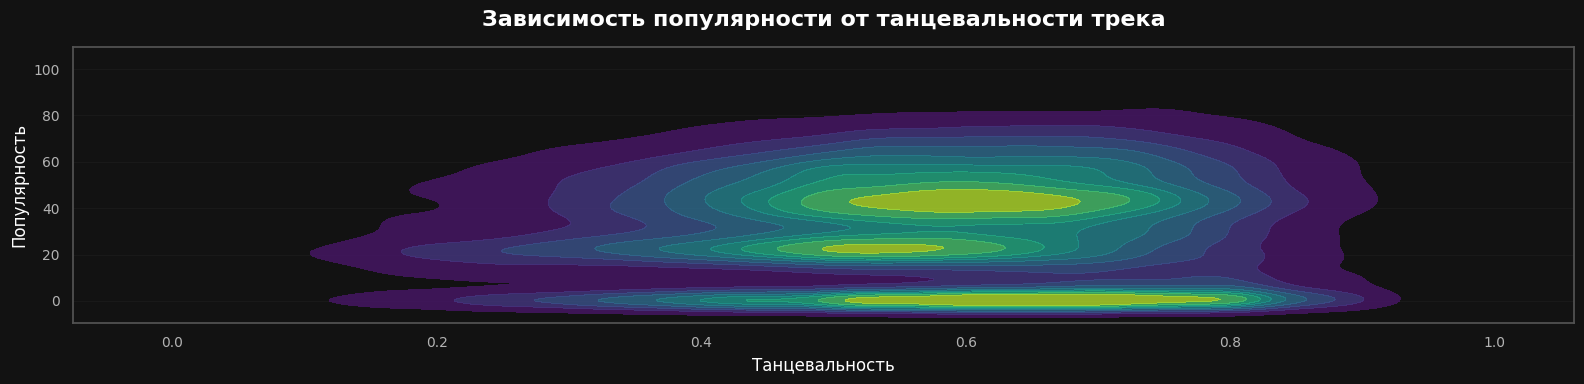

In [7]:
plt.style.use('dark_background')
sns.set_theme(style="dark",
              rc={'figure.facecolor': '#121212',
                  'axes.facecolor':   '#121212',
                  'axes.edgecolor':   '#535353',
                  'axes.labelcolor':  '#FFFFFF',
                  'axes.titlecolor':  '#FFFFFF',
                  'xtick.color':      '#B3B3B3',
                  'ytick.color':      '#B3B3B3',
                  'grid.color':       '#282828',
                  'text.color':       '#FFFFFF',
              })
plt.figure(figsize=(16, 4))
# KDE plot с заполнением в зелёных тонах Spotify
sns.kdeplot(data=df,
            x="danceability",
            y="popularity",
            cmap="viridis",
            fill=True,
            levels=10,              # количество уровней плотности
            thresh=0.05,            # порог отсечения слабой плотности
            alpha=0.8)
plt.title("Зависимость популярности от танцевальности трека", fontsize=16, fontweight='bold', color='#FFFFFF', pad=15)
plt.xlabel("Танцевальность", fontsize=12, color='#FFFFFF')
plt.ylabel("Популярность", fontsize=12, color='#FFFFFF')
# Метки осей
plt.xticks(fontsize=10, color='#B3B3B3')
plt.yticks(fontsize=10, color='#B3B3B3')
plt.grid(color='#282828', linestyle='-', linewidth=0.5, axis='y', alpha=0.5)
plt.tight_layout()

На графике представлена двумерная оценка плотности распределения KDE - контурныйграфик плотности между признаком танцевальности трека и метрикой популярности.

- Максимальная концентрация треков наблюдается в интервале danceability 0.50–0.80 и популярности 30–70.
- При danceability < 0.3 или > 0.9 плотность резко падает во всех диапазонах популярности. Треки с экстремально низкой, почти не танцевальной, или экстремально высокой танцевальностью (почти монотонный бит) редко достигают высокой популярности.
- Треки с danceability в интервале 0.55–0.80 имеют наибольшую вероятность попасть в средний и высокий сегмент популярности (50-90+).
- Треки с danceability < 0.25 ,то есть медленные, атмосферные, акустические, классические, практически не встречаются среди треков с популярностью > 60-70.  
- Треки с danceability > 0.90 очень монотонные, гипер-танцевальные лупы, также редко превышают 70–80 баллов популярности.

Наблюдаются два относительно выраженных максимума. основной - danceability примерно 0.65, popularity примерно 55–60. вторичный - danceability примерно 0.40–0.45, popularity примерно 20–40.тут возможно, инди, альтернативные и более меланхоличные треки.

#### Вывод
Анализ графика показывает слабую выраженность тенденции к большей популярности треков с высокой танцевальностью. то есть танцевальность может способствовать популярности, но сама по себе не выступает надёжным и доминирующим фактором успеха трека.

***4. Наличие нецензурной лексики влияет на популярность трека***

/tmp/ipython-input-1667704880.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='explicit', y='popularity', palette=[ '#0A3D1A', spotify_green ], errorbar=None)


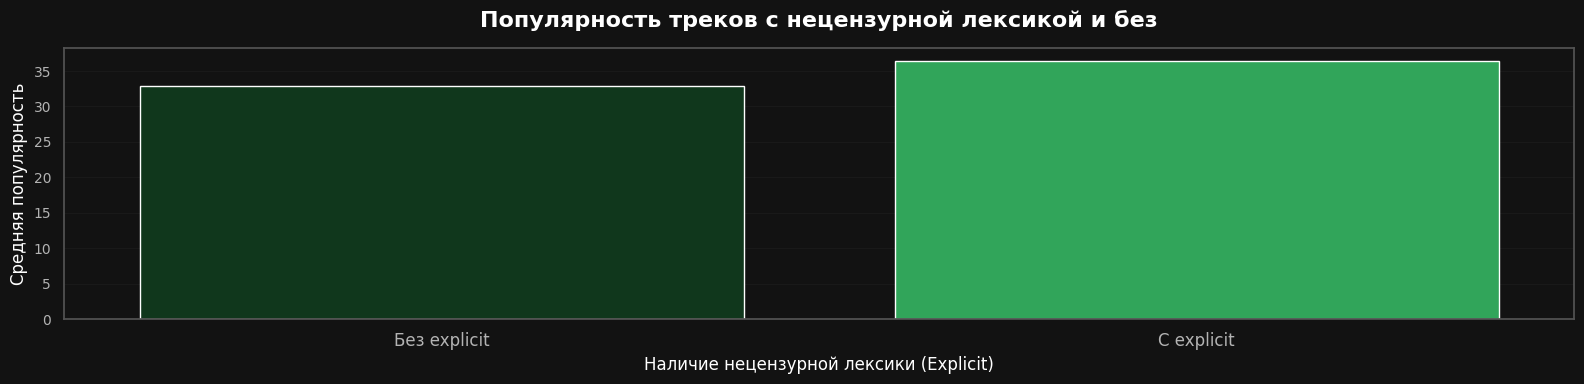

In [8]:
plt.style.use('dark_background')
sns.set_theme(style="dark",
              rc={'figure.facecolor': '#121212',
                  'axes.facecolor':   '#121212',
                  'axes.edgecolor':   '#535353',
                  'axes.labelcolor':  '#FFFFFF',
                  'axes.titlecolor':  '#FFFFFF',
                  'xtick.color':      '#B3B3B3',
                  'ytick.color':      '#B3B3B3',
                  'grid.color':       '#282828',
                  'text.color':       '#FFFFFF',
              })

plt.figure(figsize=(16, 4))
spotify_green = '#1DB954'
sns.barplot(data=df, x='explicit', y='popularity', palette=[ '#0A3D1A', spotify_green ], errorbar=None)
plt.title("Популярность треков с нецензурной лексикой и без", fontsize=16, fontweight='bold', color='#FFFFFF', pad=15)
plt.xlabel("Наличие нецензурной лексики (Explicit)", fontsize=12, color='#FFFFFF')
plt.ylabel("Средняя популярность", fontsize=12, color='#FFFFFF')
plt.xticks([0, 1], ['Без explicit', 'С explicit'], fontsize=12, color='#B3B3B3')
plt.yticks(fontsize=10, color='#B3B3B3')
plt.grid(color='#282828', linestyle='-', linewidth=0.5, axis='y', alpha=0.5)
plt.tight_layout()

На графике представлена столбчатая диаграмма, показывающая среднее значение метрики популярности для двух групп треков:  
- без метки explicit   
- с меткой explicit
  

Средняя популярность треков без explicit примерно 32–34. Средняя популярность треков с explicit примерно34–36. Разница составляет примерно 2–4  в пользу треков с нецензурной лексикой.

#### Вывод

Наличие метки explicit связано с незначительно более высокой средней популярностью треков, однако эта связь носит косвенный характер и обусловлена преимущественным присутствием explicit в доминирующих массовых жанрах, а не прямым влиянием нецензурной лексики на восприятие аудитории.

***5. Популярность трека зависит от его жанра***

In [9]:
len(df['track_genre'].unique()) # посмотрим, сколько всего жанров есть в датасете

114

/tmp/ipython-input-309445133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_popularity, x='track_genre', y='popularity', palette='viridis') # Создание столбчатой диаграммы


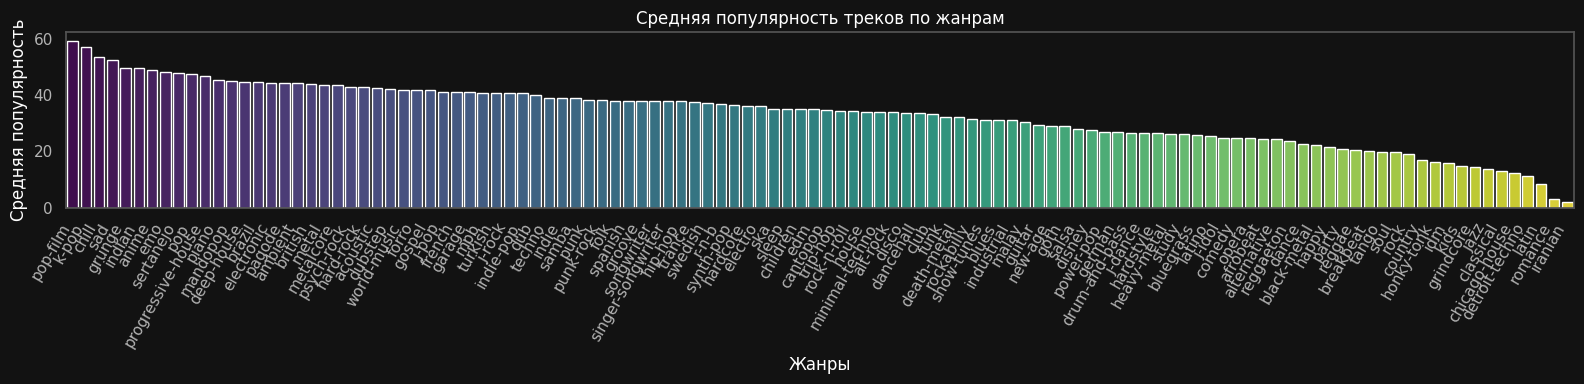

In [10]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().reset_index()
genre_popularity = genre_popularity.sort_values(by='popularity', ascending=False) # Сортировка по популярности
plt.figure(figsize=(16, 4)) # Установка размера графика
sns.barplot(data=genre_popularity, x='track_genre', y='popularity', palette='viridis') # Создание столбчатой диаграммы
plt.title('Средняя популярность треков по жанрам')
plt.xticks(rotation=60, ha='right')  # Угол текста и выравнивание
plt.ylabel('Средняя популярность')
plt.xlabel('Жанры')
plt.tight_layout()  # Оптимизирует отступы для читаемости

Самые популярные жанры имеют среднюю популярность в диапазоне 55–60 баллов, наименее популярные 0–10 баллов. Это указывает на значительную неоднородность популярности между жанрами в данной выборке.
  Наиболее высокие значения демонстрируют жанры:  
  - pop  
  - progressive house  
  - sertanejo  
  - anime  
  - electro house  
  и ряд других близких к мейнстримной и танцевальной,электронной музыке.  

Значительное количество жанров, особенно нишевые, экспериментальные и региональные, имеют среднюю популярность ниже 20-25 баллов. К ним относятся, в частности:  
  - минимальные поджанры техно/хауса (minimal, minimal-techno)  
  - тяжёлые и экстремальные направления (death-metal, black-metal, grindcore)  
  - традиционные и фолк-жанры с низким охватом в стриминге (iranian, turkish, forro, romance и др.)

#### Вывод

Жанр является значимым фактором, влияющим на среднюю популярность трека. Поп- и танцевально-электронные направления устойчиво занимают верхние позиции, тогда как нишевые, экстремальные, традиционные и экспериментальные жанры демонстрируют существенно более низкие значения популярности. При этом линейная корреляция между аудио-признаками и популярностью была крайне слабой, что подчёркивает важность категориальных факторов над чисто акустическими характеристиками.

***6. Расперделение плотности и энергии и танцевальности***

Возможно, чем танцевальнее и энергичнее музыка, тем она популярнее. Посмотрим на распределениие плотности этих данных, чтобы соотнести диапазоном популярности.

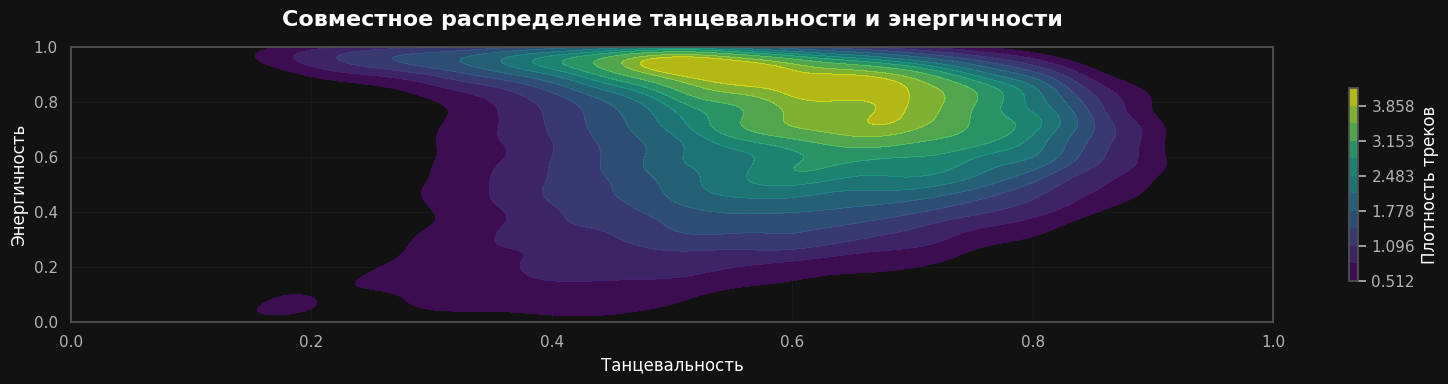

In [11]:
plt.style.use('dark_background')
sns.set_theme(style="dark",
              rc={'figure.facecolor': '#121212',
                  'axes.facecolor':   '#121212',
                  'axes.edgecolor':   '#535353',
                  'axes.labelcolor':  '#FFFFFF',
                  'axes.titlecolor':  '#FFFFFF',
                  'xtick.color':      '#B3B3B3',
                  'ytick.color':      '#B3B3B3',
                  'grid.color':       '#282828',
                  'text.color':       '#FFFFFF',
              })
plt.figure(figsize=(16, 4))
sns.kdeplot(data=df, x='danceability', y='energy',
    fill=True,
    cmap='viridis',
    levels=12,
    thresh=0.1,
    alpha=0.8,
    cbar=True,                    # встроенная цветовая шкала
    cbar_kws={'label': 'Плотность треков', 'shrink': 0.7}
)
plt.title('Совместное распределение танцевальности и энергичности', fontsize=16, fontweight='bold', pad=15, color='#FFFFFF')
plt.xlabel('Танцевальность', fontsize=12, color='#FFFFFF')
plt.ylabel('Энергичность', fontsize=12, color='#FFFFFF')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(color='#282828', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()

На представленном графике изображена двумерная оценка плотности распределения (KDE с заполнением) между признаками танцевальности (danceability, ось X) и энергичностис(energy, ось Y) для всех треков в выборке. Цветовая интенсивность и температура отражает плотность треков.

- пик плотности расположена в зоне danceability 0.55-0.75  energy  0.65–0.90  
- Плотность имеет выраженный одновершинный характер с вытянутым эллиптическим ядром. Максимальная концентрация треков приходится на область умеренно-высокой танцевальности и высокой энергичности.
- danceability < 0.3 и energy < 0.3 то есть нижний левый угол - практически пустая зона. очень мало акустических, спокойных, медленных треков  
- danceability > 0.9 и energy примерно 1.0 правый верхний угол -  плотность заметно снижается. очень монотонные, гипер-ритмичные треки без мелодической вариативности встречаются редко
- danceability  0.0-0.2 при любой энергичности крайне низкая плотность. почти отсутствуют треки с минимальной ритмической составляющей
- Подавляющее большинство треков в выборке сосредоточено в правой верхней четверти графика, где danceability > 0.5, energy > 0.6.  
Это отражает сильный уклон датасета в сторону современной поп, танцевальной, хип-хоп, EDM музыки.

#### Вывод

Выборка смещена в сторону высокоэнергичной и умеренно-высокотанцевальной музыки, что отражает текущие предпочтения массовой аудитории и алгоритмическое продвижение на платформе. Эти показатели косвенно влияют на популярность.
Хотя на данном графике напрямую не отображена популярность, известно из предыдущих анализов, что именно зона умеренно-высокой танцевальности (0.55–0.80) и высокой энергичности (0.65–0.90) содержит наибольшую долю треков с высокой популярностью. Таким образом, пик плотности на графике совпадает с золотой зоной современных хитов.

***7. Матрица корреляции***

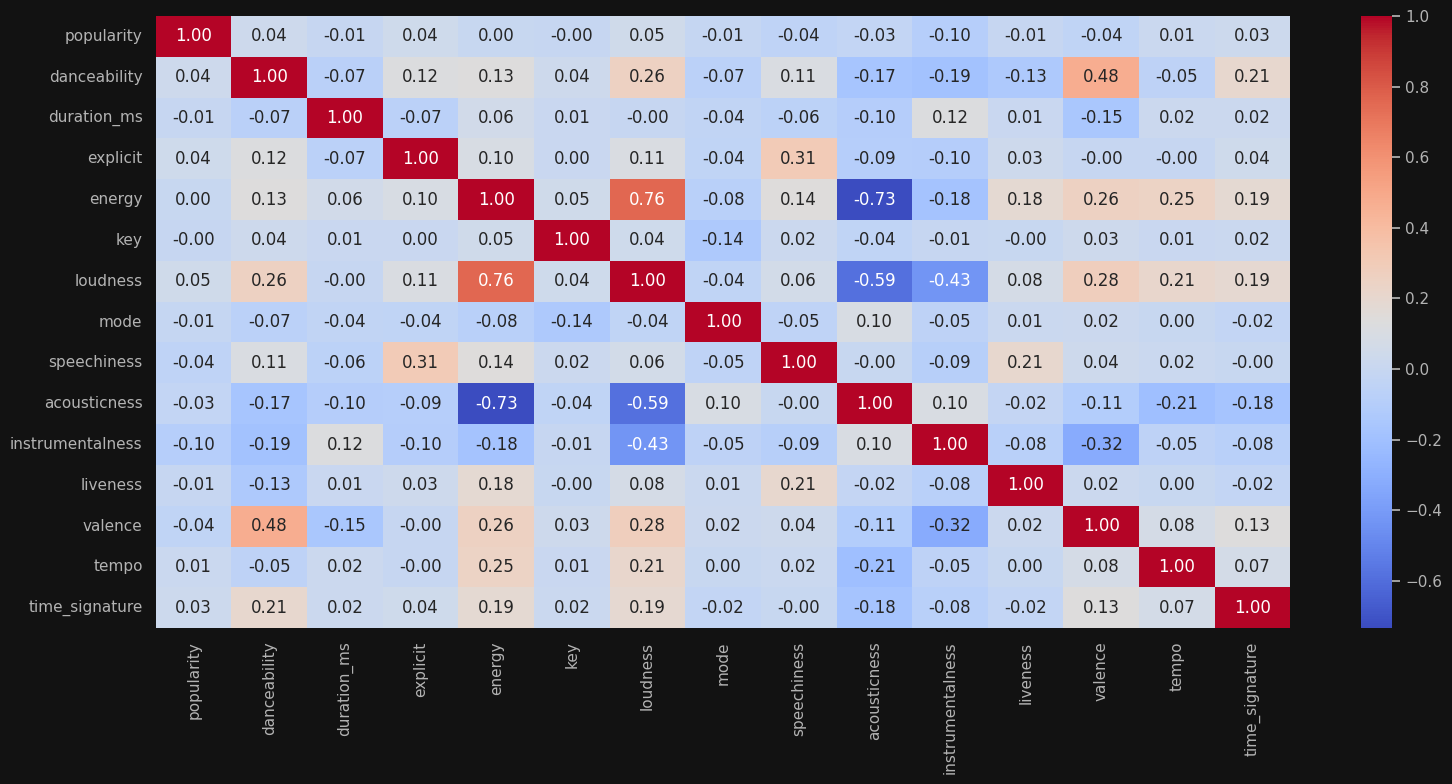

In [12]:
corr_list = df.loc[:, ['popularity', 'danceability', 'duration_ms', 'explicit', 'energy', 'key', 'loudness', 'mode', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']]
corr_df = corr_list.corr()
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(data=corr_df, fmt='.2f', annot=True, cmap='coolwarm', ax=ax)
plt.tight_layout()

In [13]:
corr_popularity = corr_df['popularity'][1:] # допполнительно посмотрим корреляцию только с популярность
corr_popularity

,popularity
danceability,0.035448
duration_ms,-0.007101
explicit,0.044082
energy,0.001056
key,-0.003853
loudness,0.050423
mode,-0.013931
speechiness,-0.044927
acousticness,-0.025472
instrumentalness,-0.095139


***Наиболее значимые взаимосвязи***
1. **energy - loudness**  
   r = 0.76  
   Сильная положительная корреляция. Более громкие треки (высокий показатель loudness) характеризуются высокой энергетикой. Это одна из наиболее ожидаемых и устойчивых зависимостей в данных.

2. **energy - acoustiness**  
   r = -0.73  
   Сильная отрицательная корреляция. Треки с высокой энергетикой практически не содержат акустического характера (низкий acoustiness). Обратная ситуация также подтверждается, поскольку акустические композиции, как правило, обладают низкой энергией.

3. **loudness - acoustiness**  
   r = -0.59  
   Умеренно сильная отрицательная связь. Чем выше акустичность трека, тем ниже его громкость. Связь логична, так как акустические записи чаще выполняются без значительной компрессии и мастеринга громкости.

4. **valence - danceability**  
   r = 0.48  
   Умеренная положительная корреляция. Более позитивные по настроению треки (высокий valence) чаще обладают высокой танцевальностью. Это одна из наиболее выраженных эмоционально-ритмических зависимостей в наборе.

5. **instrumentalness - speechiness**  
   r = -0.43  
   Умеренная отрицательная корреляция. Треки с высокой долей вокала/речи (speechiness) практически не бывают инструментальными и наоборот. Связь отражает естественное разделение песен и инструментальной музыки.

6. **liveness - valence**  
   r = -0.32  
   Умеренная отрицательная связь. Более живые (концертные, присутствующие) записи чаще характеризуются менее позитивным эмоциональным окрасом (ниже valence).

7. **mode - loudness**  
   r = -0.43
   Умеренная отрицательная корреляция. Треки в минорном ладу (mode = 0) в среднем несколько громче мажорных. Связь относительно слабая и может быть специфична для выборки.

8. **energy - valence**  
   r = 0.26–0.28
   Слабая положительная связь. Более энергичные треки несколько чаще имеют позитивный эмоциональный окрас, однако зависимость выражена неярко.

***Связь признаков с целевой переменной popularity***

Все коэффициенты корреляции признаков с `popularity` находятся в диапазоне от -0.13 до +0.05. Ни один из аудио-признаков не демонстрирует сколько-нибудь значимой линейной связи с популярностью трека в данной выборке.

Наиболее заметные зависимости:

- **valence** - r = +0.048  
  Слабый положительный тренд. Более позитивные треки чуть чаще встречаются среди популярных.

- **danceability** - r = +0.04  
  Слабый положительный тренд. Повышенная танцевальность незначительно ассоциирована с большей популярностью.

- **liveness** - r = -0.10  
  Слабая отрицательная связь. Треки с признаками концертной записи несколько реже попадают в высоко-популярные позиции.

- **instrumentalness** - r = -0.10  
  Слабая отрицательная связь. Полностью инструментальные композиции в среднем менее популярны.

#### Вывод

Корреляция между аудио-признаками и метрикой популярности крайне слабые. Это говорит о том, что популярность трека в значительной степени определяется факторами, не входящими в данный набор признаков (алгоритмическое продвижение, социальный контекст, плейлисты, известность исполнителя, тренды, вирусность и др.).